In [1]:
import os
import time
import sys
import tqdm
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams["lines.linewidth"] = 2.0

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.datasets import CIFAR100
from torchvision import transforms
import math
import torch.utils.data as data
from torch.utils.data import DataLoader
from functools import partial

In [2]:
data_path = "./data_path"
checkpoint_path = "./checkpoint_path"

def set_seed(seed):
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0")if torch.cuda.is_available()else torch.device("cpu")

print("using this device", device)

using this device cuda:0


In [3]:
import urllib.request
from urllib.error import HTTPError

data_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial6/"

pretrained_filename = ["ReverseTask.ckpt", "SetAnomalyTask.ckpt"]

os.makedirs(checkpoint_path, exist_ok = True)



def pretrain_filename(data_url:str, pretrained_filename:str):
  for file_name in pretrained_filename:
    file_path = os.path.join(checkpoint_path, file_name)
    if not os.path.isfile(file_path):
      # Removed the erroneous line: os.path.dirname(file_path.rsplit("/",1))
      file_url = data_url + file_name
      print(f"Downloading this file_url {file_url}")

      try:
        urllib.request.urlretrieve(file_url, file_path)
      except HTTPError as e:
          print(f"downloading this model from the link above\n", e)


if __name__ == "__main__":
  pretrain_filename(data_url, pretrained_filename)



##Transformer Architecture
(1) Scaled_dot_product

In [4]:
import math

In [5]:
def scale_product(q, k, v , mask = None):
  d_k = q.size()[-1]
  attn_logits = torch.matmul(q, k.transpose(-2, -1))
  attn_logit = attn_logits / math.sqrt(d_k)
  if mask is not None:
    attn_logit = attn_logit.masked_fill(mask ==0, -9e-15)
  attention = F.softmax(attn_logit, dim = -1)
  values = torch.matmul(attention, v)
  return values, attention

In [6]:
d_k, seq_len = 5, 3
q = torch.randn(d_k, seq_len)
k = torch.randn(d_k, seq_len)
v = torch.randn(d_k, seq_len)

values, attention = scale_product(q, k, v)
print("values", values)
print("attention", attention)
print("q", q)
print("k", k)
print("v", v)

values tensor([[ 0.2371,  0.1247,  0.0980],
        [ 0.3130, -0.0914,  0.0144],
        [ 0.2248,  0.1681, -0.0277],
        [ 0.2260,  0.1626,  0.0822],
        [ 0.2778, -0.0035,  0.0273]])
attention tensor([[0.2531, 0.1669, 0.2117, 0.1941, 0.1742],
        [0.0911, 0.2621, 0.2566, 0.1952, 0.1951],
        [0.2839, 0.0780, 0.3666, 0.1767, 0.0948],
        [0.3231, 0.1677, 0.1842, 0.1716, 0.1535],
        [0.0846, 0.1559, 0.3598, 0.2230, 0.1768]])
q tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890]])
k tensor([[ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950],
        [ 0.2815,  0.0562,  0.5227],
        [-0.2384, -0.0499,  0.5263]])
v tensor([[-0.0085,  0.7291,  0.1331],
        [ 0.8640, -1.0157, -0.8887],
        [ 0.1498, -0.2089, -0.3870],
        [ 0.9912,  0.4679, -0.2049],
        [-0.7409,  0

Multi-Head-attention Mechanism

In [7]:
def expand_mask(mask):
  assert mask.ndim >= 2, "the mask dimensionality must be greater than two"
  if mask.ndim ==3:
    mask = mask.unsqueeze(1)
  while mask.ndim < 4:
    mask = mask.unsqueeze(0)
  return mask

In [8]:
class MultiheadAttentionMechanism(nn.Module):
  def __init__(self, input_dim, embed_dim, numhead_dim):
    super().__init__() # Added super().__init__()
    assert embed_dim % numhead_dim == 0, "embed_dim must be divisible by numhead_dim"

    self.input_dim = input_dim
    self.embed_dim = embed_dim
    self.numhead_dim = numhead_dim
    self.head_dim = embed_dim // numhead_dim

    # Moved from create_model and fixed variable references to self.attributes
    self.qkv_proj = nn.Linear(self.input_dim, 3 * self.embed_dim)
    self.o_proj = nn.Linear(self.embed_dim, self.input_dim)

    self._reset_parameters()

  # Removed the create_model method as its logic is now in __init__

  def _reset_parameters(self):
    nn.init.xavier_uniform_(self.qkv_proj.weight)
    self.qkv_proj.bias.data.fill_(0)
    nn.init.xavier_uniform_(self.o_proj.weight)
    self.o_proj.bias.data.fill_(0)



  def forward(self, x, mask = None, return_attention = False):
    batch_size, seq_len, _ = x.size()
    if mask is not None:
      mask = expand_mask(mask)
    qkv = self.qkv_proj(x)

    # Corrected reshape to separate numhead_dim and 3*head_dim
    qkv = qkv.reshape(batch_size, seq_len, self.numhead_dim, 3 * self.head_dim)
    qkv = qkv.permute(0, 2, 1, 3)
    q, k, v = qkv.chunk(3, dim= -1)

    values, attention = scale_product(q, k, v, mask)
    values = values.permute(0, 2, 1, 3)
    values = values.reshape(batch_size, seq_len, self.embed_dim)
    o = self.o_proj(values)

    if return_attention:
      return o, attention
    else:
      return o

Encoder_Block

In [9]:
class Encoder_Block(nn.Module):
  def __init__(self, input_dim, numhead_dim,feedforward_dim, drop_out = 0.0):
    super().__init__()


    self.multi_head = MultiheadAttentionMechanism(input_dim, input_dim, numhead_dim)






    self.norm1 = nn.LayerNorm(input_dim)
    self.norm2 = nn.LayerNorm(input_dim)
    self.dropout = nn.Dropout(drop_out)


    self.linear_net = nn.Sequential(
        nn.Linear(input_dim, feedforward_dim),
        nn.Dropout(drop_out),
        nn.ReLU(inplace = True),
        nn.Linear(feedforward_dim, input_dim)
    )




  def forward(self, x, mask = None, return_attention = False):
    attn_output = self.multi_head(x, mask = mask, return_attention = return_attention)

    if return_attention:
        attention, attn_maps = attn_output
    else:
        attention = attn_output
        attn_maps = None

    x = x + self.dropout(attention)
    x = self.norm1(x)


    linear_out = self.linear_net(x)
    x = x + self.dropout(linear_out)
    x = self.norm2(x)

    if return_attention:
        return x, attn_maps
    else:
        return x

In [10]:
class Encoder_Block(nn.Module):
  def __init__(self, input_dim, numhead_dim,feedforward_dim, drop_out = 0.0):
    super().__init__()


    self.multi_head = MultiheadAttentionMechanism(input_dim, input_dim, numhead_dim)



    self.linear_net = nn.Sequential(
        nn.Linear(input_dim, feedforward_dim),
        nn.Dropout(drop_out),
        nn.ReLU(inplace = True),
        nn.Linear(feedforward_dim, input_dim)
    )



    self.norm1 = nn.LayerNorm(input_dim)
    self.norm2 = nn.LayerNorm(input_dim)
    self.drop_out = nn.Dropout(drop_out)

  def forward(self, x, mask = None):
    x = self.multi_head(x, mask = mask)
    x = x + self.drop_out(x)
    x = self.norm1(x)


    linear_out = self.linear_net(x)
    x = x + self.drop_out(linear_out)
    x = self.norm2(x)

    return x





Transformer-Encoder

In [11]:
class Transformer_Encoder(nn.Module):
  def __init__(self, num_layers, **block_args):
    super().__init__()

    self.layers = nn.ModuleList([Encoder_Block(**block_args) for _ in range(num_layers)])


  def forward(self, x, mask = None):
    for layer in self.layers:
      x = layer(x, mask = mask)
    return x


  def _get_attention_maps(self, x, mask = None):
    attention_maps = []
    for layer in self.layers:
      _, attn_map_single_layer = layer.multi_head(x, mask = mask, return_attention = True)
      attention_maps.append(attn_map_single_layer)
    return attention_maps

Positional_Encoding

In [12]:
class Positional_encoding(nn.Module):
  def __init__(self, d_model, seq_len = 5000, device = torch.device("cpu")):
    super().__init__()


    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len, device = device, dtype = torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/ d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    pe = pe.unsqueeze(0)

    self.register_buffer("pe", pe, persistent = True)


  def forward(self, x):
    x = x + self.pe[:, :x.size(1)]
    return x

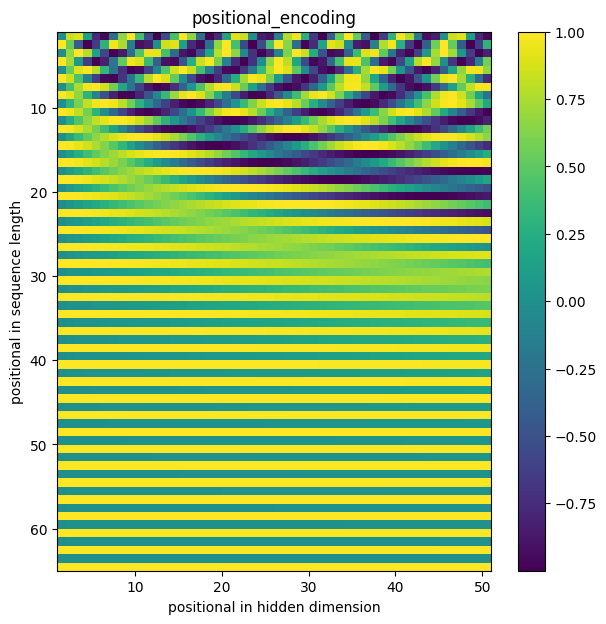

In [13]:
positional_info = Positional_encoding(d_model = 64, seq_len = 50, device = torch.device("cpu"))
pe_encod_values = positional_info.pe.squeeze().T.cpu().numpy()
fig, ax = plt.subplots(figsize = (7,7)) # Modified to create a single subplot
pos = ax.imshow(pe_encod_values, cmap = "viridis", aspect = "auto", extent = (1, pe_encod_values.shape[1]+1, pe_encod_values.shape[0]+1,1)) # Explicitly plotting on ax
fig.colorbar(pos, ax = ax)
ax.set_title("positional_encoding")
ax.set_xlabel("positional in hidden dimension")
ax.set_ylabel("positional in sequence length")
plt.show()

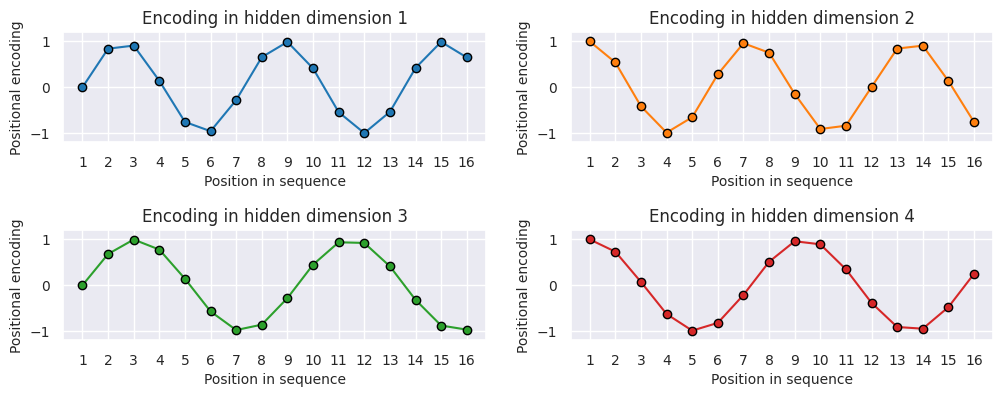

In [14]:
sns.set_theme()
fig, ax = plt.subplots(2, 2, figsize=(12,4))
ax = [a for a_list in ax for a in a_list]
for i in range(len(ax)):
    ax[i].plot(np.arange(1,17), pe_encod_values[i,:16], color=f'C{i}', marker="o", markersize=6, markeredgecolor="black")
    ax[i].set_title(f"Encoding in hidden dimension {i+1}")
    ax[i].set_xlabel("Position in sequence", fontsize=10)
    ax[i].set_ylabel("Positional encoding", fontsize=10)
    ax[i].set_xticks(np.arange(1,17))
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].tick_params(axis='both', which='minor', labelsize=8)
    ax[i].set_ylim(-1.2, 1.2)
fig.subplots_adjust(hspace=0.8)
sns.reset_orig()
plt.show()

Learning Rate Parameters (Cosine-Learning-Rate-warm-up)

In [15]:
import torch.optim as optim

In [16]:
class Cosine_Learning_rate(optim.lr_scheduler._LRScheduler):
  def __init__(self, optimizer, warm_up, max_iter):
    self.optimizer = optimizer
    self.warm_up = warm_up
    self.max_num_iter = max_iter
    super().__init__(optimizer)


  def get_lr(self):
    lr_factor = self.get_lr_factor(epoch = self.last_epoch)
    return [base_lr * lr_factor for base_lr in self.base_lrs]


  def get_lr_factor(self, epoch):
    lr_factor = 0.5 * (1+ np.cos(np.pi * epoch / self.max_num_iter))
    if epoch <= self.warm_up:
      lr_factor *= epoch * 1.0 / self.warm_up
    return lr_factor

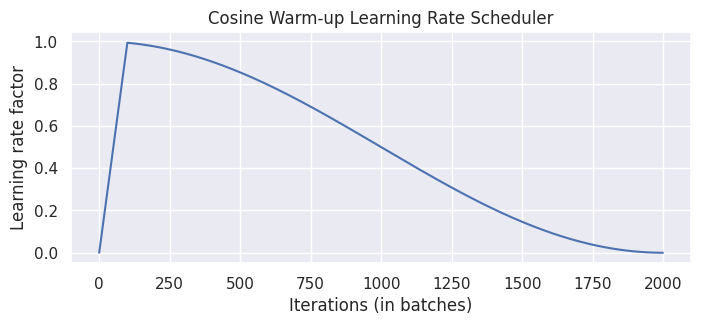

In [17]:
p = nn.Parameter(torch.empty(4,4))
pe = optim.Adam([p], lr = 1e-5)
learning_rate_scheduler = Cosine_Learning_rate(optimizer = pe, warm_up = 100, max_iter = 2000)
epochs = list(range(2000))
sns.set()
plt.figure(figsize=(8,3))
plt.plot(epochs, [learning_rate_scheduler.get_lr_factor(e) for e in epochs])
plt.ylabel("Learning rate factor")
plt.xlabel("Iterations (in batches)")
plt.title("Cosine Warm-up Learning Rate Scheduler")
plt.show()
sns.reset_orig()

In [18]:
!pip install --quiet pytorch_lightning
!pip install --quiet pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.7 MB/s eta 0:00:00


In [19]:
import pytorch_lightning as pl

Pytorch_Lightning Module for transformer Modules

In [20]:
class Transformer_model(pl.LightningModule):
  def __init__(self, input_dim, model_dim, num_classes, num_layers, numhead_dim, max_iter, lr, warm_up, input_dropout = 0.0, drop_out = 0.0):
    super().__init__()
    self.save_hyperparameters()
    self._create_model()

  def _create_model(self):
    self.input_net = nn.Sequential(
        nn.Linear(self.hparams.input_dim, self.hparams.model_dim),
        nn.Dropout(self.hparams.input_dropout)
    )


    self.positional_encoding = Positional_encoding(d_model = self.hparams.model_dim)

    self.transformer = Transformer_Encoder(
        num_layers = self.hparams.num_layers,
        input_dim = self.hparams.model_dim,
        numhead_dim = self.hparams.numhead_dim,
        feedforward_dim = 2*self.hparams.model_dim,
        drop_out = self.hparams.drop_out

    )


    self.output_net = nn.Sequential(
        nn.Linear(self.hparams.model_dim, self.hparams.model_dim),
        nn.Dropout(self.hparams.drop_out),
        nn.ReLU(inplace = True),
        nn.Linear(self.hparams.model_dim, self.hparams.num_classes)
    )

  # The forward method should be a direct member of the class, not nested in _create_model
  def forward(self, x, mask = None, add_positional_encoding = True):
    x = self.input_net(x)
    if add_positional_encoding:
      x = self.positional_encoding(x)
    attention_maps = self.transformer(x, mask = mask)
    x = self.output_net(attention_maps)
    return x



  @torch.no_grad()
  def get_attention_maps(self, x, mask = None, add_positional_encoding = True):
    x = self.input_net(x)
    if add_positional_encoding:
      x = self.positional_encoding(x)
    attention_maps = self.transformer._get_attention_maps(x, mask = mask)
    return attention_maps





  def configure_optimizers(self):
    optimizer = optim.Adam(self.parameters(), lr = self.hparams.lr)
    lr_scheduler = Cosine_Learning_rate(optimizer = optimizer, warm_up = self.hparams.warm_up, max_iter = self.hparams.max_iter)
    return [optimizer], {"scheduler":lr_scheduler, "interval":"step"}




  def training_step(self, batch, batch_idx):
    raise NotImplementedError

  def validation_step(self, batch, batch_idx):
    raise NotImplementedError


  def test_step(self, batch, batch_idx):
    raise NotImplementedError

In [21]:
class ReverseDataset(data.Dataset):
  def __init__(self, num_categories, seq_len, size):
    self.size = size
    self.num_categories = num_categories
    self.seq_len = seq_len

    self.data = torch.randint(self.num_categories, size = (self.size, self.seq_len))

  def __len__(self):
    return self.size


  def __getitem__(self, idx):
    label = self.data[idx]
    target = torch.flip(label, dims=(0,)) # Corrected: flip along sequence dimension
    return label, target

In [22]:
Dataset = partial(ReverseDataset, 10, 20)
train_loader = data.DataLoader(Dataset(50000), batch_size = 256, shuffle = True, pin_memory_device = True, num_workers = 0)
val_loader = data.DataLoader(Dataset(2000), batch_size = 256, shuffle = False, pin_memory_device = True, num_workers = 0)
test_loader = data.DataLoader(Dataset(10000), batch_size = 256, shuffle = False, pin_memory_device = True, num_workers = 0)

Sequence to Sequence(Machine Translation)

In [23]:
label, target = train_loader.dataset[0]
print("label", label)
print("target", target)

label tensor([5, 9, 1, 5, 1, 9, 1, 4, 0, 3, 7, 5, 7, 1, 5, 7, 5, 8, 5, 4])
target tensor([4, 5, 8, 5, 7, 5, 1, 7, 5, 7, 3, 0, 4, 1, 9, 1, 5, 1, 9, 5])


In [24]:
class ReversePredictor(Transformer_model):
    def _calculate_loss(self, batch, mode = "train"):
        label, target = batch
        inp_data = F.one_hot(label, num_classes = self.hparams.num_classes).float()
        pred = self.forward(inp_data, add_positional_encoding = True)
        # Corrected the arguments for F.cross_entropy
        loss = F.cross_entropy(pred.view(-1, pred.size(-1)), target.view(-1))
        acc = (pred.argmax(dim = -1) == target).float().mean()
        self.log(f"{mode}_loss", loss)
        self.log(f"{mode}_acc", acc)
        return loss, acc



    def training_step(self,batch, batch_idx):
        loss, _ = self._calculate_loss(batch, mode = "train")
        return loss

    def validation_step(self,batch, batch_idx):
        _ = self._calculate_loss(batch, mode = "val")


    def test_step(self, batch, batch_idx):
        _ = self._calculate_loss(batch, mode = "test")

In [25]:
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

In [26]:
def train_reverse(**kwargs):
  root_dir = os.path.join(checkpoint_path, "Reversepredict")
  os.makedirs(root_dir, exist_ok = True)
  trainer = pl.Trainer(default_root_dir = root_dir,
                       max_epochs = 10,
                       callbacks = [ModelCheckpoint(save_weights_only = True, monitor = "val_acc", mode = "max"),LearningRateMonitor("epoch")])
  trainer.logger._log_graph = True
  trainer.logger._default_hp_metrics = None



  pretrained_filename = os.path.join(checkpoint_path, "Reversepredict.ckpt")
  if os.path.isfile(pretrained_filename):
    print(f"downloading this file name {pretrained_filename}")
    model = ReversePredictor.load_from_checkpoint(pretrained_filename)
  else:
    pl.seed_everything(42)
    model = ReversePredictor(max_iter = trainer.max_epochs * len(train_loader), **kwargs)
    trainer.fit(model, train_loader, val_loader)

  val_results = trainer.validate(model, val_loader, verbose = False)
  test_results = trainer.test(model, test_loader, verbose = False)

  results = {"val_acc":val_results[0]["val_acc"], "test_acc":test_results[0]["test_acc"]}

  model = model.to(device)
  return model, results

In [27]:
reverse_model, reverse_results = train_reverse(input_dim =train_loader.dataset.num_categories,
                                               model_dim = 256,
                                               numhead_dim = 8,
                                               num_classes = train_loader.dataset.num_categories,
                                               num_layers = 1,
                                               drop_out = 0.0,
                                               lr = 1e-4,
                                               warm_up = 100
                                               )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_net           │ Sequential          │  2.8 K │ train │     0 │
│ 1 │ positional_encoding │ Positional_encoding │      0 │ train │     0 │
│ 2 │ transformer         │ Transformer_Encoder │  527 K │ train │     0 │
│ 3 │ output_net          │ Sequential          │ 68.4 K │ train │     0 │
└───┴─────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 598 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 598 K                                                                                                
Total estimated model params size (MB): 2.393                                                                      
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [28]:
print(f"Val accuracy:  {(100.0 * reverse_results['val_acc']):4.2f}%")
print(f"Test accuracy: {(100.0 * reverse_results['test_acc']):4.2f}%")

Val accuracy:  100.00%
Test accuracy: 100.00%


In [29]:
print(f"the test accuracy of the model is {(100 *reverse_results["test_acc"]):4.2f}%")
print(f"the val accuracy of the model is {(100 * reverse_results["val_acc"]):4.2f}%")

the test accuracy of the model is 100.00%
the val accuracy of the model is 100.00%


In [30]:
label, target = next(iter(val_loader))
inp_data = F.one_hot(label, num_classes = reverse_model.hparams.num_classes).float()
inp_data = inp_data.to(device)
attention_maps = reverse_model.get_attention_maps(inp_data)

In [31]:
attention_maps = attention_maps[0].shape
attention_maps

torch.Size([256, 8, 20, 20])

Set Anomaly Detection

In [32]:
train_data = CIFAR100(root =  data_path, train = True, download = True)
train_data

100%|██████████| 169M/169M [27:10<00:00, 104kB/s]


Dataset CIFAR100
    Number of datapoints: 50000
    Root location: ./data_path
    Split: Train

In [33]:
train_std = (train_data.data/255.0).std(axis = (0,1, 2))
train_mean = (train_data.data/255.0).mean(axis = (0, 1, 2))
print("train_std", train_std)
print("train_mean", train_mean)

train_std [0.26733429 0.25643846 0.27615047]
train_mean [0.50707516 0.48654887 0.44091784]


In [34]:
train_transform = transforms.Compose([transforms.ToTensor(),
                                transforms.RandomHorizontalFlip(p = 0.5),
                                transforms.RandomResizedCrop((32,32),scale = (0.8, 1.0), ratio=(0.8, 1.0)),
                                transforms.Normalize(train_mean, train_std)])
test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize(train_mean, train_std)])

train_datasets = CIFAR100(root = data_path, train = True, download = True, transform = train_transform)
val_datasets = CIFAR100(root = data_path, train = True, download = True, transform = test_transform)
test_datasets = CIFAR100(root = data_path, train = False, download = True, transform = test_transform)


In [35]:
import os
os.environ["TORCH_HOME"] = checkpoint_path
pretrained_model = torchvision.models.resnet18(weights = "IMAGENET1K_V1")
pretrained_model.fc = nn.Sequential()
pretrained_model.classifier = nn.Sequential()
pretrained_model = pretrained_model.to(device)

pretrained_model.eval()
for p in pretrained_model.parameters():
  p.required_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to ./checkpoint_path/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


In [36]:
@torch.no_grad()
def extract_feature(dataset, save_file):
  if not os.path.isfile(save_file):
    data_loader = data.DataLoader(dataset, batch_size = 128, shuffle = False, drop_last = False, num_workers = 2)
    extracted_features = []
    for img, _ in tqdm.tqdm(data_loader):
      img = img.to(device)
      feats = pretrained_model(img)
      extracted_features.append(feats)
    extracted_features = torch.cat(extracted_features, dim = 0)
    extracted_features = extracted_features.detach().cpu()
    torch.save(extracted_features, save_file)
  else:
    extracted_features = torch.load(save_file)
  return extracted_features


train_features_path = os.path.join(checkpoint_path, "train_features.pt")
train_files = extract_feature(train_datasets, train_features_path)

# Create a distinct path for test features
test_features_path = os.path.join(checkpoint_path, "test_features.pt")
test_feats = extract_feature(test_datasets, test_features_path)


100%|██████████| 79/79 [00:02<00:00, 32.52it/s]


In [37]:
print("Train_features", train_files.shape)
print("Test_features", test_feats.shape)

Train_features torch.Size([50000, 512])
Test_features torch.Size([10000, 512])


In [38]:
labels = train_datasets.targets

labels = torch.LongTensor(labels)
labels = labels.to(device)
num_labels = labels.max()+1
sorted_indices = torch.argsort(labels).reshape(num_labels, -1)

num_val_exmps = sorted_indices.shape[1] // 10

val_indices = sorted_indices[:, :num_val_exmps].reshape(-1)
train_indices = sorted_indices[:, num_val_exmps:].reshape(-1)


train_feats, train_labels = train_files[train_indices.cpu()],labels[train_indices]
val_feats, val_labels = train_files[val_indices.cpu()], labels[val_indices]

In [39]:
class setAnomalyDataset(data.Dataset):
  def __init__(self, img_feats, labels, set_size = 10, train = True):

    super().__init__()
    self.img_feats = img_feats
    self.labels = labels
    self.set_size = set_size-1
    self.train = train

    self.num_labels = labels.max().cpu().item() + 1
    self.img_idx_by_label = torch.argsort(self.labels).reshape(self.num_labels, -1)

    if not train:
      self.test_sets = self._create_test_sets()


  def _create_test_sets(self):
    test_sets = []
    num_imgs = self.img_feats.shape[0]
    np.random.seed(42)
    test_sets = [self.sample_img_set(self.labels[idx]) for idx in range(num_imgs)]
    test_sets = torch.stack(test_sets, dim =0)
    return test_sets


  def sample_img_set(self, anomaly_label):
    set_labels = np.random.randint(self.num_labels-1)

    if set_labels >= anomaly_label:
      set_labels += 1


    img_indices = np.random.choice(self.img_idx_by_label.shape[1],
                                   size = self.set_size, replace = False)
    return torch.LongTensor(img_indices)



  def __len__(self):
    return self.img_feats.shape[0]



  def __getitem__(self, idx):
    anomaly = self.img_feats[idx]
    if self.train:
      img_indices = self.sample_img_set(self.labels[idx])
    else:
      img_indices = self.test_sets[idx]


    img_set = torch.cat([self.img_feats[img_indices], anomaly[None]], dim = 0)
    indices = torch.cat([img_indices, torch.LongTensor([idx])], dim = 0)
    label = img_set.shape[0]-1


    return img_set, indices, label

In [40]:
set_sizes = 10
test_labels  = torch.LongTensor(test_datasets.targets)

train_data_anom = setAnomalyDataset(train_feats, train_labels, set_size = set_sizes, train = True)
val_data_anom = setAnomalyDataset(val_feats, val_labels, set_size = set_sizes, train = False)
test_data_anom = setAnomalyDataset(test_feats, test_labels, set_size = set_sizes, train = False)


tranom_loader = data.DataLoader(train_data_anom, batch_size = 256, shuffle = True, pin_memory_device = True, num_workers = 0)
valnom_loader = data.DataLoader(val_data_anom, batch_size = 256, shuffle = False, pin_memory_device = True, num_workers = 0)
testom_loader = data.DataLoader(test_data_anom, batch_size = 256, shuffle = False, pin_memory_device = True, num_workers = 0)

In [41]:
class AnomalyPredictor(Transformer_model):
  def _calculate_loss(self, batch, mode = "train"):
    labels, _, target = batch
    pred = self.forward(labels, add_positional_encoding = False)

    # The anomaly is always the last token in the sequence (index -1)
    # Select the prediction corresponding to the anomaly token
    pred_anomaly_token = pred[:, -1, :]

    loss = F.cross_entropy(pred_anomaly_token, target)
    acc = (pred_anomaly_token.argmax(dim = -1)== target).float().mean()
    self.log(f" {mode}_loss", loss)
    self.log(f"{mode}_acc", acc)

    return loss, acc


  def training_step(self, batch, batch_idx):
    loss, _ = self._calculate_loss(batch, mode = "train")
    return loss

  def validation_step(self, batch, batch_idx):
    _ = self._calculate_loss(batch, mode = "val")

  def test_step(self, batch, batch_idx):
    _ = self._calculate_loss(batch, mode = "test")

In [42]:
def train_anomaly(**kwargs):
    # Create a PyTorch Lightning trainer with the generation callback
    root_dir = os.path.join(checkpoint_path, "SetAnomalyTask")
    os.makedirs(root_dir, exist_ok=True)
    trainer = pl.Trainer(default_root_dir=root_dir,
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc")],
                         accelerator="gpu" if str(device).startswith("cuda") else "cpu",
                         devices=1,
                         max_epochs=10,
                         gradient_clip_val=2)
    trainer.logger._default_hp_metric = None # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(checkpoint_path, "SetAnomalyTask.ckpt")
    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        model = AnomalyPredictor.load_from_checkpoint(pretrained_filename)
    else:
        model = AnomalyPredictor(max_iter=trainer.max_epochs*len(tranom_loader), **kwargs)
        trainer.fit(model, tranom_loader, valnom_loader)
        model = AnomalyPredictor.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

    # Test best model on validation and test set
    train_result = trainer.test(model, tranom_loader, verbose=False)
    val_result = trainer.test(model, valnom_loader, verbose=False)
    test_result = trainer.test(model, testom_loader, verbose=False)
    result = {"test_acc": test_result[0]["test_acc"], "val_acc": val_result[0]["test_acc"], "train_acc": train_result[0]["test_acc"]}

    model = model.to(device)
    return model, result

In [43]:
def train_anomaly(**kwargs):
    root_dir = os.path.join(checkpoint_path, "SetAnomalyTask")
    os.makedirs(root_dir, exist_ok=True)

    trainer = pl.Trainer(
        default_root_dir=root_dir,
        callbacks=[
            ModelCheckpoint(
                save_weights_only=True,
                mode="max",
                monitor="val_acc"
            )
        ],
        accelerator="gpu" if str(device).startswith("cuda") else "cpu",
        devices=1,
        max_epochs=100,
        gradient_clip_val=2
    )

    trainer.logger._default_hp_metric = None
    pretrained_filename = os.path.join(checkpoint_path, "SetAnomalyTask.ckpt")
    max_iter = trainer.max_epochs * len(tranom_loader)

    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        # Override num_classes from checkpoint to ensure correct architecture
        model = AnomalyPredictor.load_from_checkpoint(
            pretrained_filename,
            num_classes=kwargs["num_classes"],
            numhead_dim=kwargs["numhead_dim"],
            warm_up=kwargs["warm_up"],
            max_iter=max_iter
        )
    else:
        model = AnomalyPredictor(max_iter=max_iter, **kwargs)
        trainer.fit(model, tranom_loader, valnom_loader)
        # Force num_classes override when loading the best model after training
        model = AnomalyPredictor.load_from_checkpoint(
            trainer.checkpoint_callback.best_model_path,
            num_classes=kwargs["num_classes"]
        )

    train_result = trainer.test(model, tranom_loader, verbose=False)
    val_result = trainer.test(model, valnom_loader, verbose=False)
    test_result = trainer.test(model, testom_loader, verbose=False)

    result = {
        "test_acc": test_result[0]["test_acc"],
        "val_acc": val_result[0]["test_acc"],
        "train_acc": train_result[0]["test_acc"]
    }

    model = model.to(device)
    return model, result

In [44]:
import os

# Define the path to the checkpoint file
pretrained_filename = os.path.join(checkpoint_path, "SetAnomalyTask.ckpt")

# Check if the file exists and delete it
if os.path.isfile(pretrained_filename):
    os.remove(pretrained_filename)
    print(f"Deleted existing checkpoint file: {pretrained_filename}")
else:
    print(f"No checkpoint file found at: {pretrained_filename}")

Deleted existing checkpoint file: ./checkpoint_path/SetAnomalyTask.ckpt


In [45]:
setanomaly_model, setanomaly_results = train_anomaly(input_dim  = train_data_anom.img_feats.shape[-1],
                                                     model_dim = 256,
                                                     numhead_dim = 8,
                                                     num_classes = 10,
                                                     num_layers = 8,
                                                     drop_out = 0.1,
                                                     input_dropout = 0.1,
                                                     lr = 1e-4,
                                                     warm_up = 50)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_net           │ Sequential          │  131 K │ train │     0 │
│ 1 │ positional_encoding │ Positional_encoding │      0 │ train │     0 │
│ 2 │ transformer         │ Transformer_Encoder │  4.2 M │ train │     0 │
│ 3 │ output_net          │ Sequential          │ 68.4 K │ train │     0 │
└───┴─────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 4.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.4 M                                                                                                
Total estimated model params size (MB): 17.666                                                                     
Modules in train mode: 107                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


...

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [46]:
print(f"the setanomaly_results val result of the odd model {(100 * setanomaly_results["val_acc"])}")
print(f"the setanomaly_results of the test_results of the odd model {(100 * setanomaly_results["test_acc"])}")
print(f"the setanomaly_results of the train_results of the odd model {(100 * setanomaly_results["train_acc"])}")

the setanomaly_results val result of the odd model 100.0
the setanomaly_results of the test_results of the odd model 100.0
the setanomaly_results of the train_results of the odd model 100.0


In [47]:
print(f"Train accuracy: {(100.0*setanomaly_results['train_acc']):4.2f}%")
print(f"Val accuracy:   {(100.0*setanomaly_results['val_acc']):4.2f}%")
print(f"Test accuracy:  {(100.0*setanomaly_results['test_acc']):4.2f}%")


Train accuracy: 100.00%
Val accuracy:   100.00%
Test accuracy:  100.00%


In [48]:
print(setanomaly_model)

AnomalyPredictor(
  (input_net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): Dropout(p=0.1, inplace=False)
  )
  (positional_encoding): Positional_encoding()
  (transformer): Transformer_Encoder(
    (layers): ModuleList(
      (0-7): 8 x Encoder_Block(
        (multi_head): MultiheadAttentionMechanism(
          (qkv_proj): Linear(in_features=256, out_features=768, bias=True)
          (o_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (linear_net): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): Dropout(p=0.1, inplace=False)
          (2): ReLU(inplace=True)
          (3): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (drop_out): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_net): Sequential(
 

In [51]:
input_data, label, target = next(iter(testom_loader))
input_data

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0225, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [2.4110, 0.0000, 0.0000,  ..., 0.7847, 2.3872, 0.6221],
         ...,
         [0.0105, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 1.8077, 0.5116,  ..., 0.0000, 0.7338, 0.0800],
         [0.5881, 0.3042, 0.0000,  ..., 1.1891, 0.1442, 0.4394]],

        [[0.2601, 0.0000, 0.0238,  ..., 0.4791, 0.2976, 0.0000],
         [1.1500, 0.0000, 0.0000,  ..., 0.3577, 0.1335, 0.1780],
         [0.6479, 0.0000, 0.4206,  ..., 0.0000, 0.0531, 0.0000],
         ...,
         [0.5860, 1.7347, 0.3184,  ..., 0.5512, 1.2802, 0.0000],
         [0.7366, 4.9747, 1.2409,  ..., 1.9268, 0.6615, 0.0000],
         [0.4733, 0.9284, 0.0000,  ..., 2.7894, 0.9788, 0.3209]],

        [[0.7455, 0.3260, 2.8110,  ..., 0.2044, 0.4233, 0.0000],
         [2.6338, 2.5199, 0.7773,  ..., 0.0849, 0.0000, 0.3806],
         [0.7400, 0.0000, 0.0000,  ..., 1.8496, 0.0000, 0.

In [52]:
input_data, label, target = next(iter(testom_loader))
input_data = input_data.to(device)
label = label.to(device)
target = target.to(device)

setanomaly_model.eval()
with torch.no_grad():
  pred = setanomaly_model.forward(input_data, add_positional_encoding = False)
  pred = F.softmax(pred.squeeze(dim = -1), dim = -1)


  pred_permut = np.random.permutation(input_data.shape[1])
  permut = input_data[:,pred_permut]
  permut = setanomaly_model.forward(permut, add_positional_encoding = False)
  permut = F.softmax(permut.squeeze(dim = -1), dim = -1)

print(f"the value of the pred\n", pred[0,pred_permut].cpu().numpy())
print(f"the value of the permut\n", permut[0].cpu().numpy())







the value of the pred
 [[3.7254038e-05 3.3842767e-05 4.2486892e-05 9.5526528e-05 2.6378500e-05
  6.9807509e-05 4.2075411e-05 2.2007991e-05 5.6044850e-05 9.9957460e-01]
 [3.7254038e-05 3.3842767e-05 4.2486856e-05 9.5526528e-05 2.6378526e-05
  6.9807509e-05 4.2075411e-05 2.2007991e-05 5.6044850e-05 9.9957460e-01]
 [3.7254002e-05 3.3842734e-05 4.2486812e-05 9.5526440e-05 2.6378500e-05
  6.9807436e-05 4.2075368e-05 2.2007969e-05 5.6044799e-05 9.9957460e-01]
 [3.7254002e-05 3.3842705e-05 4.2486812e-05 9.5526440e-05 2.6378500e-05
  6.9807436e-05 4.2075368e-05 2.2007969e-05 5.6044799e-05 9.9957460e-01]
 [3.7254038e-05 3.3842767e-05 4.2486856e-05 9.5526528e-05 2.6378500e-05
  6.9807509e-05 4.2075411e-05 2.2007991e-05 5.6044850e-05 9.9957460e-01]
 [3.7254002e-05 3.3842705e-05 4.2486856e-05 9.5526440e-05 2.6378500e-05
  6.9807436e-05 4.2075368e-05 2.2007969e-05 5.6044799e-05 9.9957460e-01]
 [3.7254038e-05 3.3842767e-05 4.2486892e-05 9.5526528e-05 2.6378526e-05
  6.9807509e-05 4.2075411e-05 2.200

In [53]:
attention_maps = setanomaly_model.get_attention_maps(input_data, add_positional_encoding = True)
attention = pred.argmax(dim = -1)
attention

tensor([[9, 9, 9,  ..., 9, 9, 9],
        [9, 9, 9,  ..., 9, 9, 9],
        [9, 9, 9,  ..., 9, 9, 9],
        ...,
        [9, 9, 9,  ..., 9, 9, 9],
        [9, 9, 9,  ..., 9, 9, 9],
        [9, 9, 9,  ..., 9, 9, 9]], device='cuda:0')

In [54]:
attention_maps


[tensor([[[[0.0667, 0.0813, 0.1042,  ..., 0.0917, 0.1222, 0.1024],
           [0.0660, 0.0840, 0.1229,  ..., 0.0802, 0.1147, 0.0817],
           [0.0624, 0.0757, 0.1127,  ..., 0.0839, 0.1069, 0.0833],
           ...,
           [0.0730, 0.0811, 0.1092,  ..., 0.0870, 0.1210, 0.0861],
           [0.0692, 0.0847, 0.0858,  ..., 0.0909, 0.1344, 0.0994],
           [0.0665, 0.0832, 0.0984,  ..., 0.0930, 0.1266, 0.0972]],
 
          [[0.1318, 0.1063, 0.0791,  ..., 0.0636, 0.0622, 0.0853],
           [0.1228, 0.1095, 0.0787,  ..., 0.0666, 0.0749, 0.0813],
           [0.1079, 0.1000, 0.0813,  ..., 0.0678, 0.0770, 0.1169],
           ...,
           [0.1051, 0.0742, 0.0596,  ..., 0.0933, 0.0932, 0.1203],
           [0.1070, 0.0859, 0.0827,  ..., 0.0924, 0.0868, 0.1090],
           [0.1021, 0.0762, 0.0732,  ..., 0.0842, 0.0846, 0.1055]],
 
          [[0.1035, 0.1040, 0.0950,  ..., 0.1270, 0.1022, 0.1077],
           [0.1324, 0.1153, 0.0996,  ..., 0.1142, 0.0843, 0.0810],
           [0.1094, 0.11